# 🛒 Superstore Sales Data Analysis

This notebook performs an end-to-end exploratory analysis of the **Sample Superstore** dataset.

**Workflow:**
1. Load & inspect the raw data
2. Clean the data (column names, types, duplicates)
3. Engineer new features (year, month, profit margin)
4. Explore key business metrics (sales, profit, categories, regions, time trends, discount impact)
5. Export a clean CSV
6. Run SQL queries against an in-memory SQLite database

**Dataset:** `Sample - Superstore.csv` — 9,994 retail orders across the United States (2014–2017).

## 1. Imports

Standard data-science stack:
- **pandas** — data manipulation and analysis
- **numpy** — numerical operations
- **matplotlib / seaborn** — static visualizations

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the Dataset

The CSV is read with `encoding='latin1'` to handle special characters present in the original file.
`df.head()` gives a quick preview of the first five rows.

In [39]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Initial Inspection

Before cleaning, we take a quick look at the dataset's shape, column names, and data types.

### 3.1 Dataset Dimensions (`df.shape`)

In [40]:
df.shape

(9994, 21)

### 3.2 Column Names (`df.columns`)

In [41]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### 3.3 Data Types & Non-Null Counts (`df.info()`)

Key observations from the raw file:
- `order_date` and `ship_date` are stored as objects — we'll convert them to `datetime`.
- `postal_code` is numeric — we'll cast it to `string` to avoid arithmetic on zip codes.
- No missing values in any column.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 4. Data Cleaning

A consistent, clean dataset is critical for reliable analysis. This section covers:
- Standardising column names
- Checking for missing values
- Fixing data types
- Identifying duplicate rows

### 4.1 Standardise Column Names

All column names are converted to **lowercase**, **underscored** form (e.g. `Sub-Category` → `sub_category`) for easier programmatic access.

In [43]:
df.columns=(
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-','_')
)

df.columns


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

### 4.2 Check for Missing Values

`df.isnull().sum()` counts `NaN` entries per column.
✅ **Result:** No missing values — the dataset is complete.

In [44]:
df.isnull().sum()

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


### 4.3 Fix Data Types

Two adjustments:
1. Convert `order_date` and `ship_date` from `object` to `datetime64` so we can extract date components.
2. Convert `postal_code` from `int64` to `string` — postal codes are identifiers, not numbers.

In [45]:
df.dtypes




,0
row_id,int64
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_id,object
customer_name,object
segment,object
country,object
city,object


In [46]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [47]:
df['postal_code'] = df['postal_code'].astype(str)


### 4.4 Check for Duplicate Rows

✅ **Result:** 0 duplicate rows found.

In [48]:
df.duplicated().sum()

np.int64(0)

## 5. Feature Engineering

Three derived columns are added to enrich the analysis:

| New Column | Formula | Purpose |
|---|---|---|
| `order_year` | `order_date.dt.year` | Year-over-year trend analysis |
| `order_month` | `order_date.dt.month` | Seasonal / monthly trend analysis |
| `profit_margin` | `profit / sales` | Efficiency metric (profit as % of revenue) |

In [49]:
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['profit_margin'] = df['profit'] / df['sales']


## 6. Exploratory Data Analysis (EDA)

We explore the data along four dimensions:
1. **Overall performance** — total sales & profit
2. **Category breakdown** — which product categories drive revenue and profit
3. **Regional breakdown** — geographic sales and profit distribution
4. **Time trends** — how monthly sales evolved from 2014 to 2017
5. **Discount vs Profit** — the relationship between discounting and profitability

### 6.1 Overall Performance

Aggregate totals for the full four-year period.

In [50]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()

total_sales, total_profit


(np.float64(2297200.8603000003), np.float64(286397.0217))

### 6.2 Sales & Profit by Category

Three product categories: **Technology**, **Furniture**, **Office Supplies**.

> **Key insight:** Technology generates the highest revenue *and* the highest profit.
> Furniture has similar revenue to Office Supplies but a much lower profit margin — heavy discounting is likely the cause.

In [51]:
category_summary = (
    df.groupby('category')[['sales', 'profit']]
      .sum()
      .sort_values(by='sales', ascending=False)
)

category_summary


,sales,profit
category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


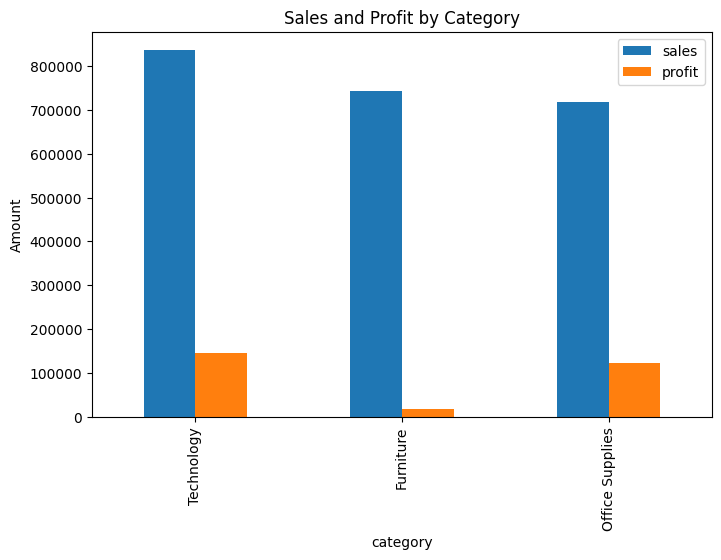

In [52]:
category_summary.plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Category')
plt.ylabel('Amount')
plt.show()


### 6.3 Sales & Profit by Region

Four US regions: **West**, **East**, **Central**, **South**.

> **Key insight:** The West region leads in both sales and profit. The Central region has notably lower profit relative to its sales volume, suggesting either higher costs or more aggressive discounting.

In [53]:
region_summary = (
    df.groupby('region')[['sales', 'profit']]
      .sum()
      .sort_values(by='sales', ascending=False)
)

region_summary


,sales,profit
region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


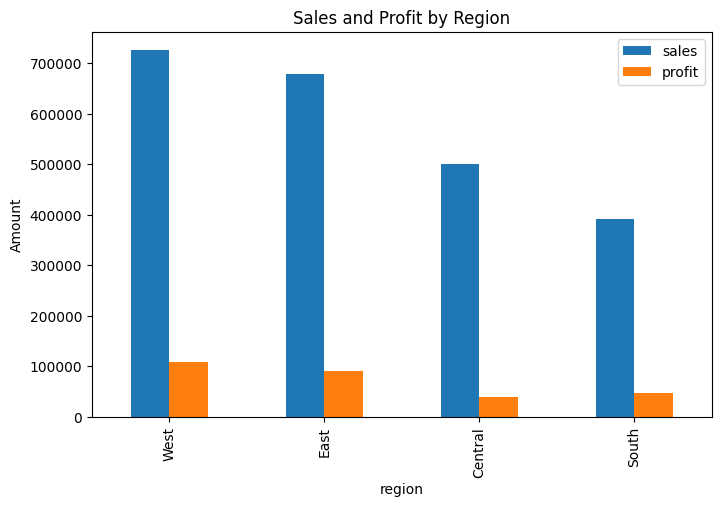

In [54]:
region_summary.plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Region')
plt.ylabel('Amount')
plt.show()


### 6.4 Monthly Sales Trend (2014–2017)

Sales are aggregated by calendar month to identify seasonality and year-over-year growth.

> **Key observations:**
> - Clear **end-of-year spikes** (September, November, December) every year.
> - A consistent **upward trend** in peak months from 2014 to 2017.
> - The weakest months are consistently January–February.

In [55]:
monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['sales']
      .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales


,sales
order_date,
2014-01-01,14236.8950
2014-02-01,4519.8920
2014-03-01,55691.0090
2014-04-01,28295.3450
2014-05-01,23648.2870
2014-06-01,34595.1276
2014-07-01,33946.3930
2014-08-01,27909.4685
2014-09-01,81777.3508


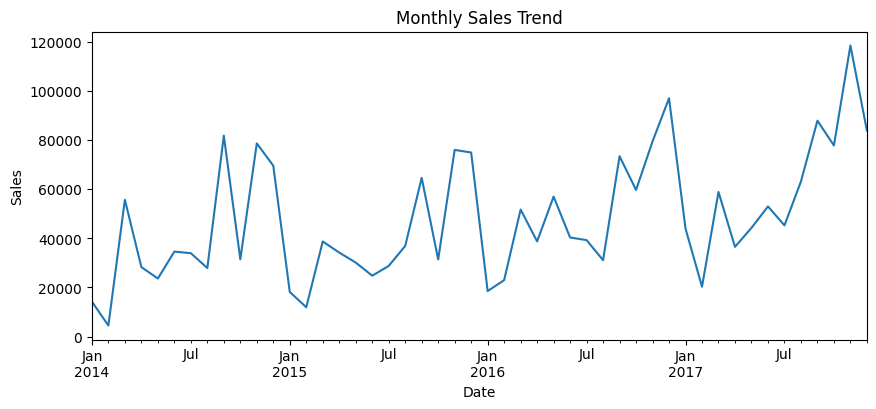

In [56]:
monthly_sales.plot(figsize=(10,4))
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.show()


### 6.5 Discount vs Profit

A scatter plot of `discount` (x-axis) against `profit` (y-axis) for every order.

> **Key insight:** There is a strong **negative correlation** between discount rate and profit.
> Orders with discounts above ~30% frequently generate losses (negative profit).
> This suggests the discount strategy should be revisited.

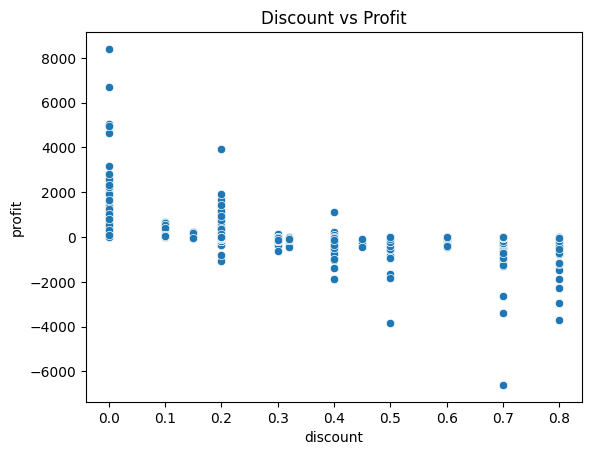

In [57]:
sns.scatterplot(data=df, x='discount', y='profit')
plt.title('Discount vs Profit')
plt.show()


## 7. Export Clean Data

The fully cleaned and feature-engineered DataFrame is saved as `clean_superstore.csv` for use in downstream tools (e.g. Tableau, Power BI).

> **Note:** The `files.download()` call below is Colab-specific and triggers a browser download. Remove it if running outside Colab.

In [58]:
df.to_csv('clean_superstore.csv', index=False)


In [59]:
from google.colab import files
files.download('clean_superstore.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. SQL Analysis

The cleaned DataFrame is loaded into an **in-memory SQLite database** so we can query it using standard SQL.
This is a lightweight alternative to a full database server — useful for ad-hoc querying within a notebook.

**Steps:**
1. Connect to (or create) `superstore.db`
2. Write the DataFrame to a table named `sales`
3. Verify the table with a simple `SELECT` query
4. Run business insight queries across products, categories, regions, and time

### 8.1 Connect to Database

In [60]:
import sqlite3

conn = sqlite3.connect('superstore.db')
cursor = conn.cursor()

### 8.2 Load DataFrame into SQL Table

In [61]:
df.to_sql(
    'sales',
    conn,
    index=False,
    if_exists='replace'
)

9994

### 8.3 Verify the Table

In [62]:
pd.read_sql("SELECT * FROM sales LIMIT 5", conn)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,profit_margin
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.4700
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.1125


### 8.4 Top 10 Most Profitable Products

Which individual products generate the most profit overall?

In [63]:
pd.read_sql("""
    SELECT product_name, ROUND(SUM(profit), 2) AS total_profit
    FROM sales
    GROUP BY product_name
    ORDER BY total_profit DESC
    LIMIT 10
""", conn)

,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04
2,Hewlett Packard LaserJet 3310 Copier,6983.88
3,Canon PC1060 Personal Laser Copier,4570.93
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98
5,Ativa V4110MDD Micro-Cut Shredder,3772.95
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.97
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.28
8,Ibico EPK-21 Electric Binding System,3345.28
9,Zebra ZM400 Thermal Label Printer,3343.54


### 8.5 Average Profit Margin by Category

How efficiently does each category convert revenue into profit?

In [64]:
pd.read_sql("""
    SELECT category, ROUND(AVG(profit_margin) * 100, 2) AS avg_margin_pct
    FROM sales
    GROUP BY category
    ORDER BY avg_margin_pct DESC
""", conn)

,category,avg_margin_pct
0,Technology,15.61
1,Office Supplies,13.80
2,Furniture,3.88


### 8.6 Loss-Making Orders by Region

Which regions have the most orders where profit was negative?

In [65]:
pd.read_sql("""
    SELECT region, COUNT(*) AS loss_orders
    FROM sales
    WHERE profit < 0
    GROUP BY region
    ORDER BY loss_orders DESC
""", conn)

,region,loss_orders
0,Central,741
1,East,553
2,West,318
3,South,259


### 8.7 Sales and Profit by Year

How have total sales and profit grown year over year?

In [66]:
pd.read_sql("""
    SELECT order_year, ROUND(SUM(sales), 2) AS total_sales, ROUND(SUM(profit), 2) AS total_profit
    FROM sales
    GROUP BY order_year
    ORDER BY order_year
""", conn)

,order_year,total_sales,total_profit
0,2014,484247.50,49543.97
1,2015,470532.51,61618.60
2,2016,609205.60,81795.17
3,2017,733215.26,93439.27


### 8.8 Sub-Categories with Negative Total Profit

Which sub-categories are losing money in aggregate?
> These are candidates for pricing or discount policy review.

In [67]:
pd.read_sql("""
    SELECT sub_category, ROUND(SUM(profit), 2) AS total_profit
    FROM sales
    GROUP BY sub_category
    HAVING total_profit < 0
    ORDER BY total_profit
""", conn)

,sub_category,total_profit
0,Tables,-17725.48
1,Bookcases,-3472.56
2,Supplies,-1189.10


## 9. Conclusion

This analysis of the Superstore dataset revealed several key business insights:

- **Technology** is the most profitable category, while **Furniture** underperforms despite similar revenue to Office Supplies.
- The **West** region leads in both sales and profit; **Central** has the weakest profit relative to its sales.
- Sales show a clear **seasonal pattern** — peaking in September, November, and December every year.
- There is a strong **negative correlation between discount and profit** — orders with discounts above ~30% frequently result in losses.
- Certain sub-categories like **Tables** and **Bookcases** generate negative profit overall and warrant a pricing review.